get data from higher_costs_ftol_1.pickle
print in a table/csv file

[Kjs, m_0, final_cost, m_values]

Table looks like this for each alpha:
cost factor | Kjs | m_0 | final_cost | m_values |

In [74]:
# get data from higher_costs_ftol_1.pickle
# print in a table/csv file

# alpha
# _____ cost factor
# [Kjs, m_0, final_cost, m_values] 

import pickle

import numpy as np

import functions as func


with open('N_16/higher_costs_ftol_1.pickle', 'rb') as f:
    data = pickle.load(f)


# get the max kj from alpha = 0.5 and cost factor = 100
print(data[0][-1][0][-1])

# get the max kj from alpha = 0.95 and cost factor = 100
print(data[-1][-1][0][-1])

55066.575775953206
92232.53225394232


In [75]:
# plot a graph of different alpha but same cost factor
import matplotlib.pyplot as plt

# get data for cost factor = 5

cost_5 = []
for i in range(len(data)):
    cost_5.append(data[i][-1])
    
func.plot_all_alpha(cost_5, 2**16, 100)
ax = plt.gca()
ax.set_xticks(range(0, 90, 10))
for spine in ax.spines.values():
    spine.set_color('black')
    
# Set tick parameters to black
ax.tick_params(axis='both', colors='black')

# Optionally turn off grid if it's on
ax.grid(False)


In [76]:
#  get data for lower bound = 5, 20, 100


with open('N_16/higher_costs_new_op_bound_5.pickle', 'rb') as f:
    lower_5 = pickle.load(f)

with open('N_16/higher_costs_all_column_lowerbound_20.pickle', 'rb') as f:
    lower_20 = pickle.load(f)
    
with open('N_16/higher_costs_all_column_lowerbound_100.pickle', 'rb') as f:
    lower_100 = pickle.load(f)
    
# get the max kj from alpha = 0.95 and cost factor = 100 for all three lower bounds
print(lower_5[-1][-1][0][-1])
print(lower_20[-1][-1][0][-1])
print(lower_100[-1][-1][0][-1])

141210.44844454818
159032.46608210859
165854.53534917423


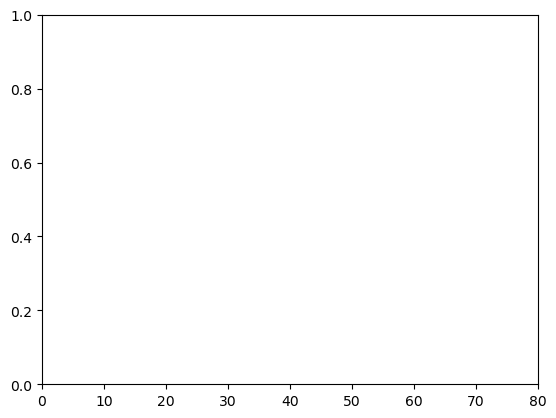

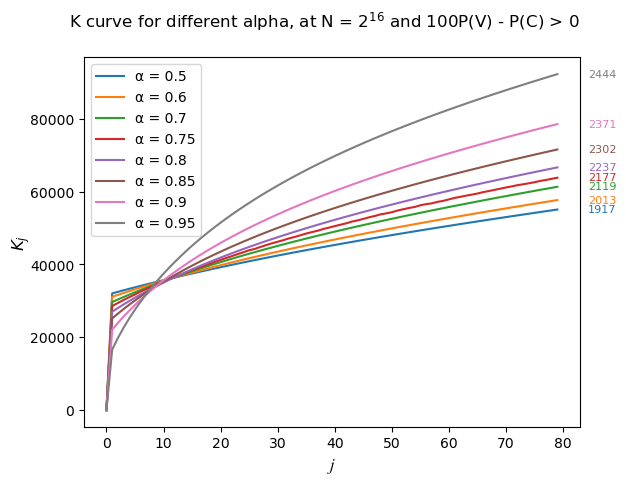

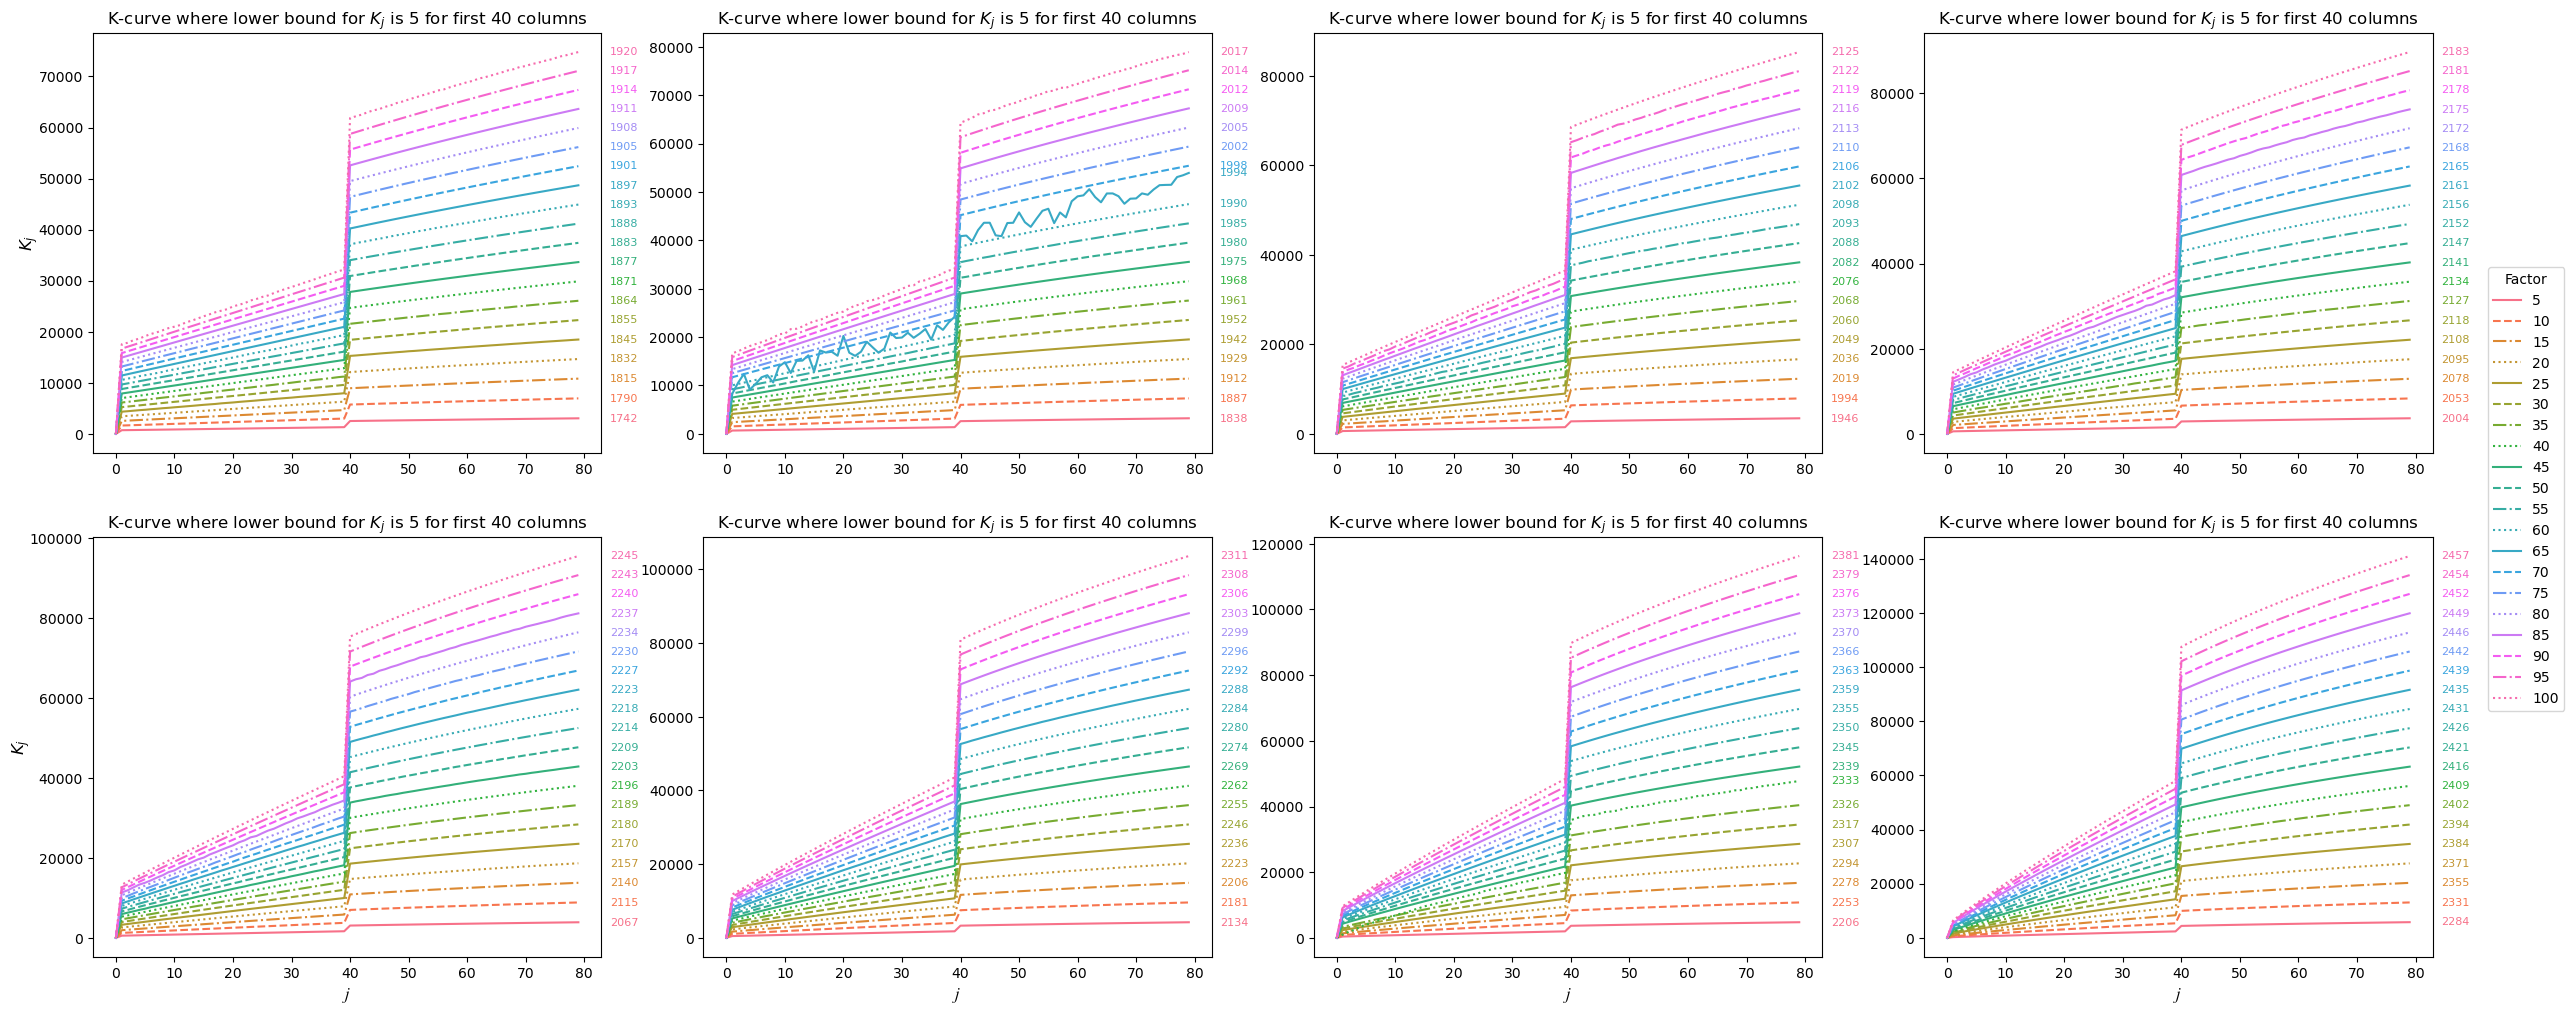

In [77]:
from importlib import reload
reload(func)

with open('N_16/lower_bound_5/lb5_5_t_80_first_40.pickle', 'rb') as f:
    data_5 = pickle.load(f)

cost_factors = list(range(5, 101, 5))
legend_label = "Factor"
alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

func.plot_all(2**16, data_5, cost_factors, legend_label, alphas) 

ax = plt.gca()
ax.set_xticks(range(0, 90, 10))
for spine in ax.spines.values():
    spine.set_color('black')
    
# Set tick parameters to black
ax.tick_params(axis='both', colors='black')

# Optionally turn off grid if it's on
ax.grid(False)

In [82]:
# column 40 value
data_5[-1][-1][0][-40]

107497.13242592468

In [83]:
# get data where all columns are lower bound 5
lower_5[-1][-1][0][-41]

74852.05616586305

In [85]:
len(data_5[-1])

20

Find spacing between curves

In [86]:
# find the coefficient of variation of the spacing between curves
def find_spacing_coefficient_of_var(data):
    # data is in the form alpha -> cost factor -> [Kjs, m_0, final_cost, m_values]
    # extract values in the last column
    last_column_vals = []
    
    # get the alpha = 0.95 plot
    data = data[-1]
    
    # for each cost factor
    for i in range(len(data)):
        # get the last column Kj values
        last_column_vals.append(data[i][0][-1])
        
    # compute spacing between adjacent curves
    spacings = np.diff(last_column_vals)
    
    
    # compute the average spacing
    mean_spacing = np.mean(spacings)
    std_spacing = np.std(spacings)
    cv = std_spacing / mean_spacing
    
    # return the coefficient of variation
    return cv

In [88]:
# find the coefficient of variation of the spacing between curves
with open('N_16/higher_costs_5_column_lowerbound_5.pickle', 'rb') as f:
    column_5 = pickle.load(f)
    
with open('N_16/higher_costs_10_column_lowerbound_5.pickle', 'rb') as f:
    column_10 = pickle.load(f)
    
with open('N_16/lower_bound_5/lb5_5_t_80_first_20.pickle', 'rb') as f:
    column_20 = pickle.load(f)
    
with open('N_16/lower_bound_5/lb5_5_t_80_first_40.pickle', 'rb') as f:
    column_40 = pickle.load(f)
    


# when 5 columns has lower bound 5
cv_5 = find_spacing_coefficient_of_var(column_5)
print(cv_5)
# when all columns have lower bound 5
cv_5_all = find_spacing_coefficient_of_var(lower_5)
print(cv_5_all)
# when 10 columns have lower bound 5
cv_10 = find_spacing_coefficient_of_var(column_10)
print(cv_10)
# when 20 columns have lower bound 5
cv_20 = find_spacing_coefficient_of_var(column_20)
print(cv_20)
# when 40 columns have lower bound 5
cv_40 = find_spacing_coefficient_of_var(column_40)
print(cv_40)


0.007882366920396495
0.04448889597420879
0.008831709025428703
0.00918543147821825
0.010363567431932584


In [90]:
print(column_5[-1][-1][0][-1])
print(column_10[-1][-1][0][-1])
print(column_20[-1][-1][0][-1])
print(column_40[-1][-1][0][-1])

98380.12595810753
105234.4719204488
117672.73532693874
141008.48431245377


In [94]:
with open('N_16/higher_costs_ftol_1.pickle', 'rb') as f:
    lower_1 = pickle.load(f)
lower_1[-1][-1][0][-1]

92232.53225394232

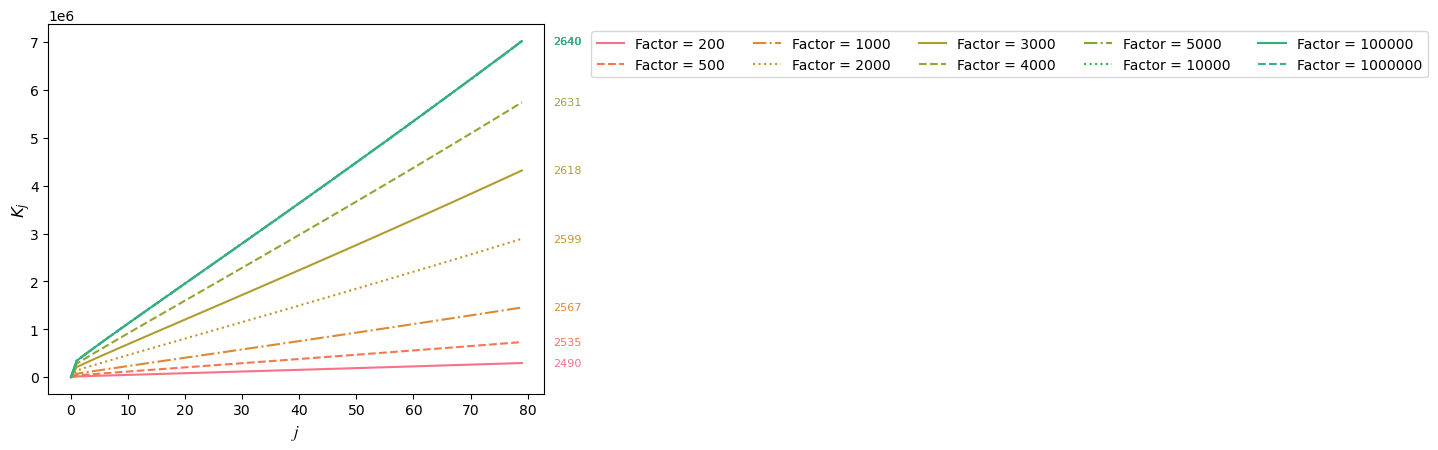

In [96]:
from importlib import reload
reload(func)

with open('N_16/much_higher_precomp/lower_bound_7_higher_cost_t_80_curves.pickle', 'rb') as f:
    lower_7 = pickle.load(f)

factors = [200, 500, 1000, 2000, 3000, 4000, 5000, 10000, 100000, 1000000]

func.plot_all_kj(2**16, lower_7, factors, legend_label, 0.95)